**6.1**

Filename: /Users/users/agstroeve/PROGNUM-repo/Task6/m101(1).fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     126   (530, 530)   int16   

SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530

The shape of the array is: (530, 530)

>i2

min=1507, max=15752, mean=4795.924268422927, std=1848.2558984219054
Mode of the data: 3551 with 876 counts
Median is: 4102.0


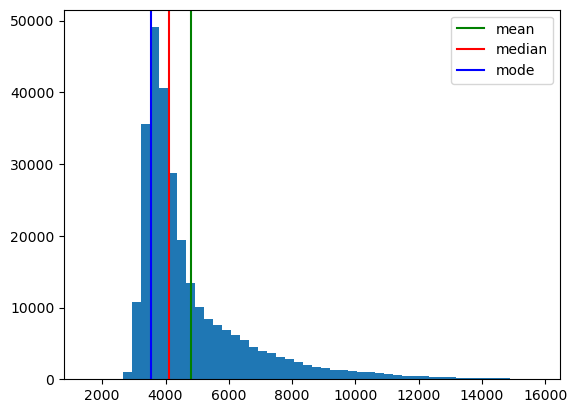

4102.0


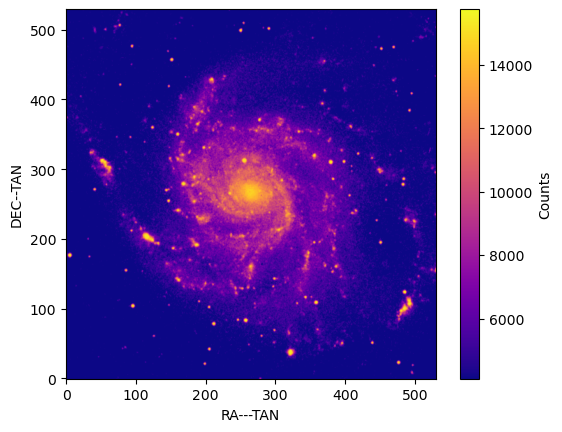

In [105]:
from astropy.io import fits
from scipy import stats
import matplotlib.pyplot as plt


hdulist = fits.open('~/PROGNUM-repo/Task6/m101(1).fits')
hdulist.info()
print() 

# there are 2 HDUs in this FITS file. The first HDU contains the image data, its index is 0. The data type is int16

hdr = hdulist[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
print()

# The value of BITPIX is 16 which corresponds with the previously stated data type int16.

dat = hdulist[0].data
print("The shape of the array is:", dat.shape)  # shape of the array confirms dimension shown using command info(), and NAXIS1 and NAXIS2 in header
print() 

print(dat.dtype)  # data type i2 means ‘signed 2-byte integer' which is a 16-bit datatype so corresponds to BITPIX = 16
print()

flatdat = dat.flatten()
s = stats.describe(flatdat)
nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(dat.flat)
print(f"min={minval}, max={maxval}, mean={mean}, std={var**0.5}")
mode, counts = stats.mode(dat.flat)
print(f"Mode of the data: {mode} with {counts} counts")

median = np.median(dat.flat)
print(f"Median is:", median)

plt.hist(flatdat, bins=50)  #histogram of flattened array
plt.axvline(mean, color ='green', label='mean')
plt.axvline(median, color ='red', label='median')
plt.axvline(mode, color ='blue', label='mode')
plt.legend()
plt.show()


datarr = np.asarray(dat, dtype='float64')
median2 = np.median(datarr)
print(median2)

hdr["BUNIT"] = "Counts"

fig = plt.figure()
frame = fig.add_subplot(1,1,1)
plt.ylabel(hdr["CTYPE2"])
plt.xlabel(hdr["CTYPE1"])
plt.imshow(datarr, origin='lower', cmap = 'plasma', vmin = median2, )
plt.colorbar(label=hdr["BUNIT"])


hdulistout = fits.PrimaryHDU(dat)
hdulistout.header = hdr    # We can copy the old header
hdulistout.writeto('~/PROGNUM-repo/Task6/m101(1).fits', overwrite=True, output_verify='ignore')
hdulist.close()

**6.3**

Description first axis: RA---TAN
Description second axis: DEC--TAN
Projection centre in R.A., Dec. is 210.80254413455 54.347395233845

15671.903529504489

3409.875283446712
261.5268188212982


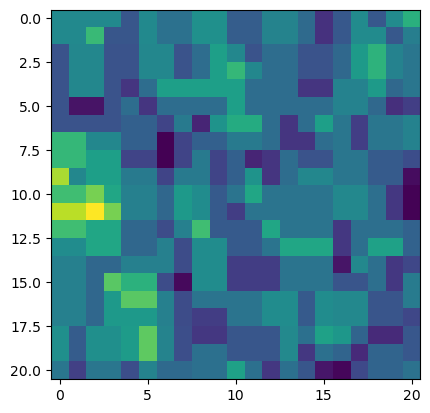

In [229]:
from math import sqrt

ctype1 = hdr['CTYPE1']
ctype2 = hdr['CTYPE2']
print("Description first axis:", ctype1)
print("Description second axis:", ctype2)

crval1 = hdr['CRVAL1']
crval2 = hdr['CRVAL2']
print("Projection centre in R.A., Dec. is", crval1, crval2)

poll = (dat[0:21, 0:21])
plt.imshow(poll)

RMS = sqrt((np.sum(poll**2.))/len(poll))
print()
print(RMS)
print()
print(np.mean(poll))
print(np.std(poll))

# RMS uses sum of the squares and then square root rather than individual deviations, std is a better way to quantify noise 


**6.5**

5.773191380233297
5.77029458336614


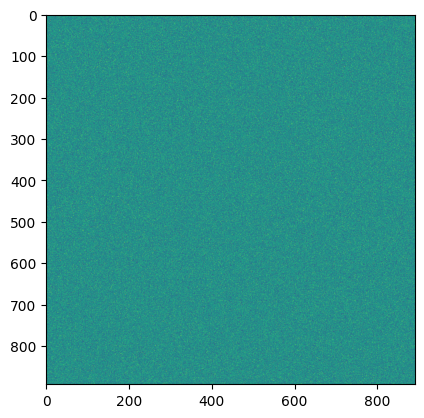

In [68]:
import numpy as np
import matplotlib.pyplot as plt 
from math import sqrt

hdulist = fits.open('~/PROGNUM-repo/Task6/noisemap0.fits')
nm0 = hdulist[0].data
hdulist = fits.open('~/PROGNUM-repo/Task6/noisemap1.fits')
nm1 = hdulist[0].data
hdulist = fits.open('~/PROGNUM-repo/Task6/noisemap2.fits')
nm2 = hdulist[0].data

dev0 = np.std(nm0)
dev1 = np.std(nm1)
dev2 = np.std(nm2)
st = np.stack((nm0, nm1, nm2), axis=0)


nmm = np.mean(st, axis=0)
plt.imshow(nmm)

print(np.std(nmm))
print(sqrt(dev0**2.+dev1**2.+dev2**2.)/3)

**6.6**

In [60]:
from astropy.io import fits
from astropy.table import Table
from math import isnan
import math

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
hdulist6 = fits.open('~/PROGNUM-repo/Task6/APOGEE_stars.fits')
arr6 = hdulist6[0].data
head = hdulist6[1].data
table = Table(head)

# Access the primary data (in this case, it is a Table)
data6 = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
print(data6.dtype)
print()
print(arr6.dtype)


table.add_column(0.0, name='DATAFLAG') 
for i in range(len(table)):
    if (table[i]['STARFLAG'] == 0 and table[i]['ASPCAPFLAG'] == 0 and table[i]['SNR'] > 10 and 
        table[i]['GAIAEDR3_PARALLAX']/table[i]['GAIAEDR3_PARALLAX_ERROR'] > 5 and
        not isnan(table[i]['GAIAEDR3_PHOT_G_MEAN_MAG']) and table[i]['GAIAEDR3_PHOT_BP_MEAN_MAG'] != "NaN"  and 
        table[i]['GAIAEDR3_PHOT_RP_MEAN_MAG'] != "NaN" ):
        table[i]['DATAFLAG']= 1
    else: 
        table[i]['DATAFLAG'] = 0


        
table.add_column(0.0, name='ABSOL_MAG') 
for i in range(len(table)):
    if table[i]['DATAFLAG'] == 0:
        table[i]['ABSOL_MAG'] = -1
    else: 
        par = table[i]['GAIAEDR3_PARALLAX']/1000
        table[i]['ABSOL_MAG'] = table[i]['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5*math.log10(par) +5

#print(table)        

#hdulistout = fits.PrimaryHDU(table)
#hdulistout.header = head    # We can copy the old header
table.write('APOGEE_update.fits')


(numpy.record, [('GAIAEDR3_PARALLAX', '>f4'), ('GAIAEDR3_PARALLAX_ERROR', '>f4'), ('GAIAEDR3_PHOT_G_MEAN_MAG', '>f4'), ('GAIAEDR3_PHOT_BP_MEAN_MAG', '>f4'), ('GAIAEDR3_PHOT_RP_MEAN_MAG', '>f4'), ('ASPCAPFLAG', '>i8'), ('STARFLAG', '>i8'), ('SNR', '>f4')])

uint8


**6.7**

42489404.0

    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


[10.062657  10.2064705 10.778471  ... 19.249237  20.236973  17.761206 ]

Average of m0 = 25.68840037029536 


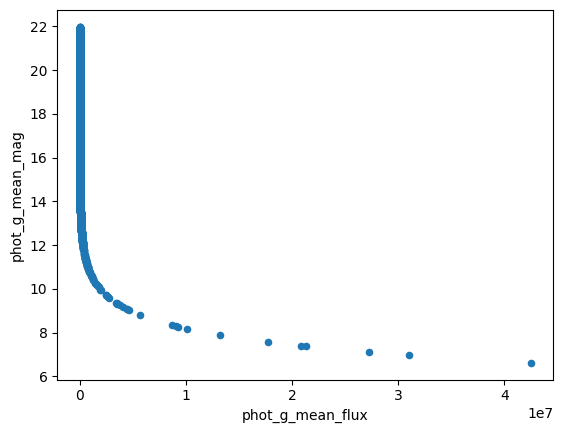

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


gaia = pd.read_csv('gaiaTestData.csv')  # read dataframe 

maxi = gaia.phot_g_mean_flux.max()  #maximum of phot_g_mean_flux
print(maxi)
print()
print(gaia.loc[gaia['phot_g_mean_flux'] == maxi ])  #find where phot_g_mean_flux is maximum
print()
gaia.plot.scatter(x='phot_g_mean_flux', y='phot_g_mean_mag')  #plot flux against magnitude 
print()
mag = np.array(gaia.phot_g_mean_mag)  #turn column mag into an array
flux = np.array(gaia.phot_g_mean_flux)  # turn column flux into an array
print(mag)
m0 = mag + (5/2)*np.log10(flux)  #calculate m0 as an array 
m0_avg = sum(m0)/len(m0)  # calculate the average value of m0
print()
print(f"Average of m0 =", m0_avg,"")  #print results

**6.10**

In [91]:
from astroquery.gaia import Gaia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits



query = """
SELECT TOP 50 
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax > 5
    AND parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

job = Gaia.launch_job(query)
results = job.get_results()

print(f"Retrieved {len(results)} stars")
print(f"\nResult type: {type(results)}")
results
pan = results.to_pandas()

hdu6 = fits.PrimaryHDU(data=pan)
hdul6 = fits.HDUList([hdu6])

hdul6.writeto('astroquery_gaia.fits')



Retrieved 36 stars

Result type: <class 'astropy.table.table.Table'>


In [92]:
hdulist7 = fits.open('~/PROGNUM-repo/Task6/astroquery_gaia.fits')
arr7 = hdulist7[0].data
print(arr7)

[[ 1.78860093e+18  3.19245823e+02  1.89753433e+01  5.58463257e+00
   5.14158344e+00  2.08420620e+01  2.16376419e+01  1.98058720e+01]
 [ 5.87310627e+18  2.23300769e+02 -6.45020051e+01  1.54835884e+01
   5.04519749e+00  2.10505199e+01  2.14338322e+01  1.97522678e+01]
 [ 3.46555167e+18  1.79955445e+02 -3.51323683e+01  1.16333849e+01
   5.06647730e+00  2.08793449e+01  2.14228878e+01  1.99999084e+01]
 [ 5.87038288e+18  2.03931118e+02 -5.82191404e+01  8.09332537e+00
   5.65342379e+00  2.06789455e+01  2.21934586e+01  1.95596066e+01]
 [ 6.06280309e+18  2.01597174e+02 -5.71076684e+01  8.33965806e+00
   5.62163925e+00  2.08844795e+01  2.15622730e+01  1.99518032e+01]
 [ 5.67635739e+18  1.40665317e+02 -2.09462029e+01  5.19738394e+00
   5.08234262e+00  2.09342690e+01  2.12427197e+01  1.97065868e+01]
 [ 4.16186554e+18  2.64720718e+02 -1.23314076e+01  1.00457189e+01
   5.01624441e+00  2.08215179e+01  2.17493458e+01  2.01268806e+01]
 [ 1.83476980e+18  3.01080201e+02  2.55488042e+01  1.35573342e+01
   

**6.14**

In [13]:

class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self, n, M):
        self.cache = [0,1]  # starting numbers 
        self.dd = n
        self.ss = M
    def __call__(self):
        if self.dd < len(self.cache):  # if n is already computed return cache 
            return self.cache[n]
        else: 
            a = 0
            b = 1 
            i=len(self.cache)
            while i<self.dd:
                number = a + b   # compute the next fibonacci number 
                self.cache.append(number)  # add calculated value to cache 
                a, b = b, number 
                i+=1
            return self.cache[-1]
        
    def calc(self):
        list1=[]
        for i in self.cache:
            if i%self.ss == 0:
                list1.append(i)
        return(list1)
            
    #def __calc__(self, n): 
    #    list1 = []
    #    for i in self.cache:  # for a number i in the cache 
    #        if i%M == 0:  # if can be divided by M
    #            list1.append(i)
    #        print(list1)

term = Fibonacci(100, 7)
print(term.__call__())
print(term.calc())
    
    #for i in range(-1, n):
#print(i)
            
#print(Fibonacci(100, 7))


218922995834555169026
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]


In [3]:
fibonacci = [0, 1]
a = 0 
b = 1 
i = len(fibonacci)
lim = 5
while i < lim:
    new = a + b
    fibonacci.append(new)
    a, b = b, new
    i += 1
print(fibonacci)

[0, 1, 1, 2, 3]


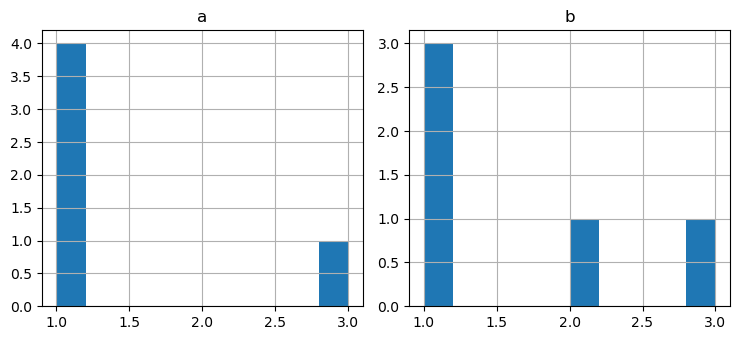

In [1]:
from matplotlib import pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True

df1 = pd.DataFrame(dict(a=[1, 1, 1, 1, 3]))
df2 = pd.DataFrame(dict(b=[1, 1, 2, 1, 3]))

fig, axes = plt.subplots(1, 2)

df1.hist('a', ax=axes[0])
df2.hist('b', ax=axes[1])

plt.show()